### Chapter 2 Coverage
This chapter covers:
- Exploring the dataset
- Creating a custom dataset
- Splitting the dataset
- Transforming the data
- Creating dataloaders
- Building the classification model
- Defining the loss function
- Defining the optimizer
- Training and evaluation of the model
- Deploying the model
- Model inference on test data

### Exploring the Dataset

In [2]:
import pandas as pd
import matplotlib.pylab as plt
from PIL import Image, ImageDraw
import numpy as np
import os
%matplotlib inline

In [3]:
path2csv = './data/train_labels.csv'

df_labels = pd.read_csv(path2csv)
df_labels.head()

,id,label
0,f38a6374c348f90b587e046aac6079959adf3835,0
1,c18f2d887b7ae4f6742ee445113fa1aef383ed77,1
2,755db6279dae599ebb4d39a9123cce439965282d,0
3,bc3f0c64fb968ff4a8bd33af6971ecae77c75e08,0
4,068aba587a4950175d04c680d38943fd488d6a9d,0


In [4]:
print(df_labels['label'].value_counts())

label
0    130908
1     89117
Name: count, dtype: int64


In [5]:
df_labels.hist()

array([[<Axes: title={'center': 'label'}>]], dtype=object)

In [6]:
malignantIDs = df_labels.loc[df_labels['label']==1]['id'].values

In [7]:
path2train = './data/train'
color = False

In [8]:
# Define figure sizes
plt.rcParams['figure.figsize'] = (10.0, 10.0)
plt.subplots_adjust(wspace=0, hspace=0)
nrows,ncols = 3,3

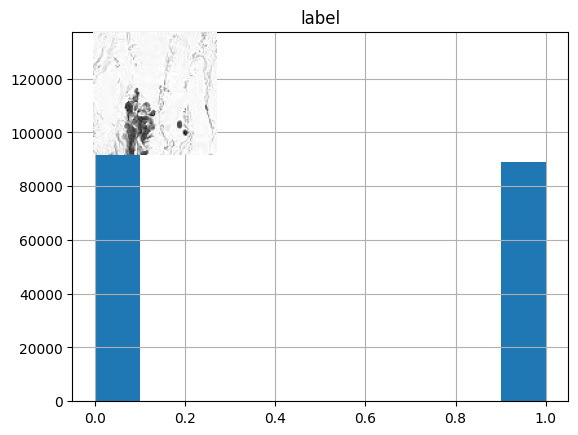

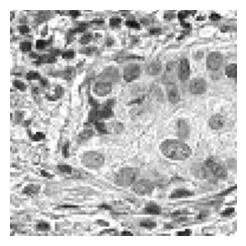

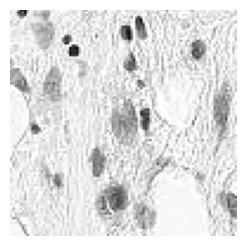

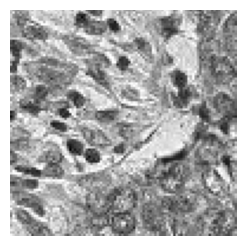

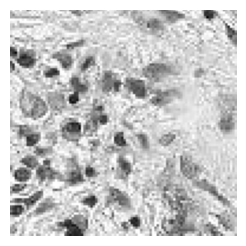

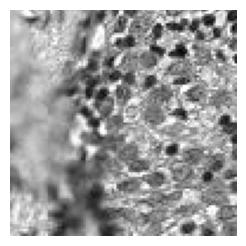

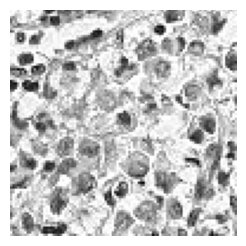

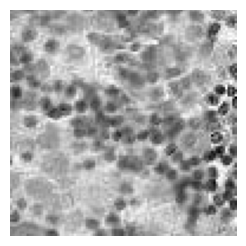

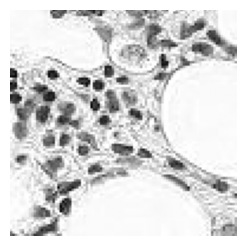

In [9]:
for i,id_ in enumerate(malignantIDs[:nrows*ncols]):
    file_names = os.path.join(path2train, id_ + '.tif')

    # load image
    img = Image.open(file_names)

    # draw 32*32 rectangles
    draw = ImageDraw.Draw(img)
    # draw.rectangle(((32,32), (64,64)), outline='green')
    plt.subplot(nrows,ncols,i+1)
    
    if color == True:
        plt.imshow(np.array(img))
    else:
        plt.imshow(np.array(img)[:,:,0], cmap='gray')
    plt.axis('off')
    plt.show()
    plt.clf()


In [10]:
print("Image shape: ", np.array(img).shape)
print("Image values range from %s to %s", np.array(img).min(), np.array(img).max())

Image shape:  (96, 96, 3)
Image values range from %s to %s 0 255


### Create a Custom Dataset

In [11]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

from PIL import Image
import pandas as pd
import os

torch.manual_seed(42)

In [12]:
class histCancerDataset(Dataset):
    
    def __init__(self, data_dir, transform, data_type='train'):

        super().__init__()

        # path to images
        path2data = os.path.join(data_dir, data_type)

        # get list of images
        filenames = os.listdir(path2data)

        # get full path to images
        self.full_filenames = [os.path.join(path2data,f) for f in filenames]

        # labels from train or test .csv
        csv_filename = data_type + '_labels.csv'
        path2csvLabel = os.path.join(data_dir,csv_filename)
        labels_df = pd.read_csv(path2csvLabel)

        labels_df.set_index("id",inplace=True)

        # obtain labels from dataframe
        self.labels = [labels_df.loc[filename[:-4]].values[0] for filename in filenames]
        
        self.transform =transform

    def __len__(self):
        return len(self.full_filenames)
        
    def __getitem__(self, idx):
        # open image apply transforms and return with label

        image = Image.open(self.full_filenames[idx]) # PIL Image
        image = self.transform(image)

        return image, self.labels[idx]
        


In [13]:
import torchvision.transforms as transforms
data_transformer = transforms.Compose([transforms.ToTensor()])

In [14]:
data_dir = './data/'

histo_dataset = histCancerDataset(data_dir=data_dir,transform=data_transformer, data_type='train')

In [15]:
print(histo_dataset.__len__())


220025


In [16]:
img, label = histo_dataset.__getitem__(idx=5)

print(img.shape, torch.min(img), torch.max(img))

torch.Size([3, 96, 96]) tensor(0.) tensor(1.)


### Splitting the Dataset

In [20]:
len_histo = histo_dataset.__len__()
len_train = 0.8*len_histo
len_val = len_histo-len_train

print(len_train)
print(len_val)

176020.0
44005.0


In [21]:
from torch.utils.data import random_split
train_ds, val_ds = random_split(histo_dataset,[int(len_train),int(len_val)])

In [23]:
for x,y in train_ds:
    print(x.shape)
    print(y)
    break

torch.Size([3, 96, 96])
1


In [24]:
for x,y in val_ds:
    print(x.shape)
    print(y)
    break

torch.Size([3, 96, 96])
0


In [25]:
# Display some images
from torchvision import utils
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)

In [36]:
def show(img, label, color=False):
    npimg=img.numpy()
    
    # Change shape C*H*W to H*W*C 
    npimg_transpose = np.transpose(npimg, (1,2,0))

    if color == False:
        npimg_transpose = npimg_transpose[:,:,0]
        plt.imshow(npimg_transpose, interpolation='nearest', cmap='gray')
    else:
        plt.imshow(npimg_transpose, interpolation='nearest')

    plt.title("Label: "+ str(y))
    plt.show()


In [40]:
# Creating sample images in grid
grid_size = 4
random_indice = np.random.randint(0, len(train_ds), grid_size)
print("Randomly selected image indices: ",random_indice)

Randomly selected image indices:  [64820   769 59735 64925]


In [43]:
x_grid_train = [train_ds[i][0] for i in random_indice]
[print(train_ds[i][1]) for i in random_indice]
y_grid_train = [train_ds[i][1] for i in random_indice]

x_grid_train=utils.make_grid(x_grid_train, nrow=4, padding=2)
print(x_grid_train.shape)

0
1
1
0
torch.Size([3, 100, 394])


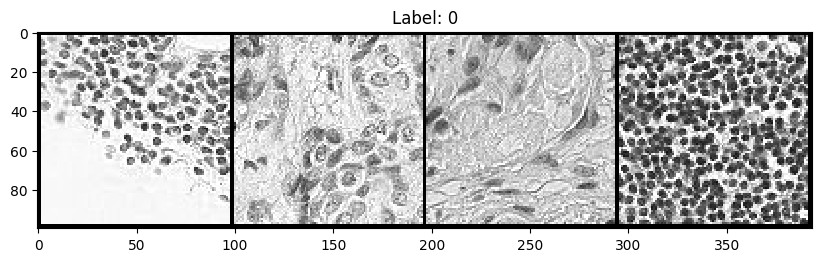

In [44]:
plt.rcParams['figure.figsize'] = (10.0, 5)
show(x_grid_train,y_grid_train)

In [50]:
## This is great usage of grid show of images
def show_grid(images, labels, nrow=4, color=False):
    n_images = len(images)
    ncol = nrow
    nrow = int(np.ceil(n_images / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3*nrow))
    axes = axes.flatten()

    for idx, (img, lbl) in enumerate(zip(images, labels)):
        # convert C×H×W → H×W×C
        npimg = img.numpy().transpose((1,2,0))
        if not color:
            npimg = npimg[:, :, 0]
            axes[idx].imshow(npimg, cmap='gray', interpolation='nearest')
        else:
            axes[idx].imshow(npimg, interpolation='nearest')

        axes[idx].set_title(f"Label: {lbl}")
        axes[idx].axis('off')

    # hide extra axes if any
    for ax in axes[len(images):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


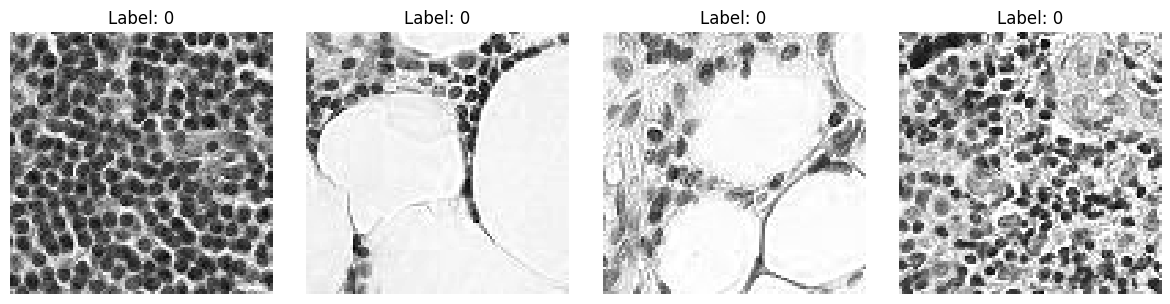

In [51]:
# Train images with label
grid_size = 4
random_indices = np.random.randint(0, len(train_ds), grid_size)

images = [train_ds[i][0] for i in random_indices]
labels = [train_ds[i][1] for i in random_indices]

show_grid(images, labels, nrow=4, color=False)

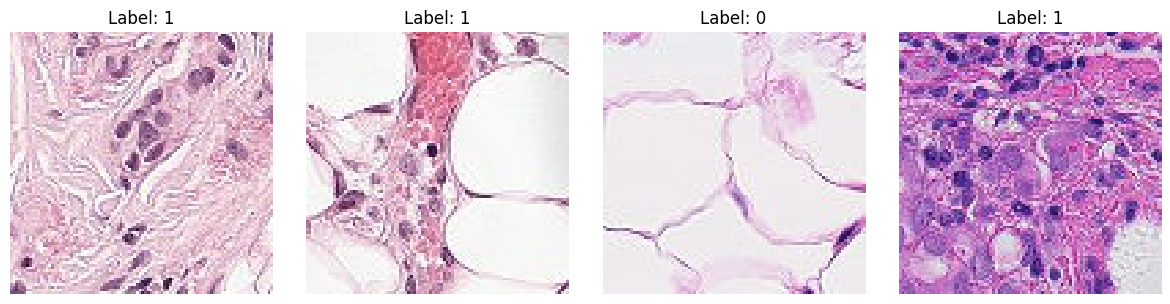

In [52]:
grid_size = 4 
random_indice = np.random.randint(0, len(val_ds), grid_size)

images = [val_ds[i][0] for i in random_indice]
labels = [val_ds[i][1] for i in random_indice]

show_grid(images, labels, nrow=4, color=True)

### Transforming the Data

In [55]:
train_transformer = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.RandomVerticalFlip(p=1),
    transforms.RandomRotation(45),
    transforms.RandomResizedCrop(96, scale=(0.8,1.0), ratio=(1.0,1.0)),
    transforms.ToTensor()
])

In [56]:
# There is no need for augmentation for val_ds
val_transformer = transforms.Compose([transforms.ToTensor()])

In [57]:
# Overwrite the tranform function
train_ds.transform = train_transformer
val_ds.transform = val_transformer